# **The Impact of Female Representation on the Profitability of Movies**
---

# **Intro to Data Science Milestone 1**
*By Andrew Yawn*

**Project Website**

[GitHub Repository](https://github.com/GabrielEpstein/DataScienceFinalPortfolio)

[Github Website](https://y4wn13.github.io/)

## **Project Goals and Approach**

**Focus:** The goal of this project is to examine and analyze whether female representation in movies has any noteworthy associations with box office returns.

**Why this matters:** Female representation in film has endured a winding journey that often aligns with the views shaping society at a given moment. From 1930 to 1968, the Hays Code imposed strict moral guidelines on films that many believe limited the number of independent female characters a movie could sustain. Female representation in movies has steadily increased since, and in 2014, FiveThirtyEight published a piece called ["The Dollar-And-Cents Case Against Hollywood’s Exclusion of Women"](https://https://fivethirtyeight.com/features/the-dollar-and-cents-case-against-hollywoods-exclusion-of-women/). This piece found that movies with more female representation earned more return on investment than those with less. This piece only examined movies up to 2013, however, and the next decade of filmmaking was marked by the #MeToo movement and seemingly more deliberate investment in movies with greater female representation. My goal is to broaden and update the analysis to see how the profitability of movies featuring female characters has changed over time and in our current moment.

I'd also like to see if I can determine whether female representation has any stastictical significance when attempting to predict a film's ROI.

**A key metric:** In 1985, a cartoonist named Alison Bechdel drew a comic that unwittingly set the standard for measuring female representation in movies for the next four decades. The comic showed two women opting not to see a movie because it did not pass three criteria:

*   There must be at least two women
*   A conversation between two women
*   A conversation between two women about anything but a man



The Bechdel Test was born, and despite its flaws, it remains the only popular standard by which female representation in movies is judged. I will be using the Bechdel Test as a key feature in this data project to categorize the level of female representation in a movie.

**Data:** I will begin this project using two datasets:


*   [9000+ Movies : IMDb and Bechdel](https://www.kaggle.com/datasets/nliabzd/movies-imdb-and-bechdel-information)
*   [TMDB + IMDB Merged Movies Dataset](https://www.kaggle.com/datasets/ggtejas/tmdb-imdb-merged-movies-dataset)

The first contains data for more than 9,000 films including, crucially, associated Bechdel Test scores (scale: 0-3). The data was scraped from BechdelTest.com, a website that crowdsources Bechdel scores from hundreds to thousands of users per movie.

The second contains data for more than 350,000 films pertaining to budget, revenue, genre, and other, mostly categorical labels such as language, production company and cast. It is also rife with duplicate movie IDs and movie ratings. I am planning to merge the data sets on movie title and IMDB identification numbers.

Due to file size, I uploaded the data to my Google Drive for use here.

#**Extraction, Transformation, Loading**

First, I must load and tidy the datasets.

Below, I am importing libraries that will allow me to analyze and later visualize this data.


**Importing libraries:**

In [1]:
import pandas as pd
import numpy as np
import string
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_rows", None, "display.max_columns", None, 'max_colwidth', None)

**Mounting Google Drive:** I am using Google Drive for this because my TMDB + IMDB Merged Movies Dataset is 280MB, too large for upload to GitHub.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
path = '/content/drive/MyDrive/Project/'

# Load the files
df_bechdel = pd.read_csv(path + 'Bechdel.csv')
df_tmdb = pd.read_csv(path + 'TMDB.csv')

# Checking first 5 rows of the Bechdel dataset
df_bechdel.head()

,title,year,imdbid,id,bechdelRating,imdbAverageRating,numVotes,runtimeMinutes,genre1,genre2,genre3
0,Miss Jerry,1894,9,9779,0,5.4,212,45,Romance,NaN,NaN
1,"Story of the Kelly Gang, The",1906,574,1349,1,6.0,903,70,Action,Adventure,Biography
2,Cleopatra,1912,2101,2003,2,5.1,622,100,Drama,History,NaN
3,A Florida Enchantment,1914,3973,4457,2,5.8,300,63,Comedy,NaN,NaN
4,"Birth of a Nation, The",1915,4972,1258,2,6.1,26403,195,Drama,History,War


In [4]:
# Checking first 5 rows of TMDB dataset
df_tmdb.head()

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,tconst,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,7/15/10,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,160000000,https://www.warnerbros.com/movies/inception,tt1375666,en,Inception,"Cobb, a skilled thief who commits corporate espionage by infiltrating the subconscious of his targets is offered a chance to regain his old life as payment for a task considered to be impossible: ""inception"", the implantation of another person's idea into a target's subconscious.",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pictures","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, france, virtual reality, kidnapping, philosophy, spy, allegory, manipulation, car crash, heist, memory, architecture, los angeles, california, dream world, subconscious",Christopher Nolan,Christopher Nolan,8.8,2794133,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken Watanabe, Tom Hardy, Elliot Page, Dileep Rao, Cillian Murphy, Tom Berenger, Marion Cotillard, Pete Postlethwaite"
1,157336,Interstellar,8.417,32571,Released,11/5/14,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,165000000,http://www.interstellarmovie.net/,tt0816692,en,Interstellar,The adventures of a group of explorers who make use of a newly discovered wormhole to surpass the limitations on human space travel and conquer the vast distances involved in an interstellar voyage.,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant to die here.,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Productions","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time, artificial intelligence (a.i.), nasa, time warp, dystopia, expedition, space travel, wormhole, famine, black hole, quantum mechanics, family relationships, space, robot, astronaut, scientist, single father, farmer, space station, curious, space adventure, time paradox, thoughtful, time-manipulation, father daughter relationship, 2060s, cornfield, time manipulation, complicated",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2492612,"Matthew McConaughey, Anne Hathaway, Michael Caine, Jessica Chastain, Casey Affleck, Wes Bentley, Topher Grace, Mackenzie Foy, Ellen Burstyn, John Lithgow"
2,155,The Dark Knight,8.512,30619,Released,7/16/08,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,185000000,https://www.warnerbros.com/movies/dark-knight/,tt0468569,en,The Dark Knight,"Batman raises the stakes in his war on crime. With the help of Lt. Jim Gordon and District Attorney Harvey Dent, Batman sets out to dismantle the remaining criminal organizations that plague the streets. The partnership proves to be effective, but they soon find themselves prey to a reign of chaos unleashed by a rising criminal mastermind known to the terrified citizens of Gotham as the Joker.",130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel Griffiths, Warner Bros. Pictures","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime fighter, superhero, anti hero, scarecrow, based on comic, vigilante, organized crime, tragic hero, anti villain, criminal mastermind, district attorney, super power, super villain, neo-noir",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Goyer, Bob Kane",9.1,3142775,"Christian Bale, Heath Ledger, Aaron Eckhart, Michael Caine, Maggie Gyllenhaal, Gary Oldman, Morgan Freeman, Monique Gabriela C

In [5]:
# Inspecting structure
df_bechdel.info()
df_tmdb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9718 entries, 0 to 9717
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              9718 non-null   object 
 1   year               9718 non-null   int64  
 2   imdbid             9718 non-null   int64  
 3   id                 9718 non-null   int64  
 4   bechdelRating      9718 non-null   int64  
 5   imdbAverageRating  9718 non-null   float64
 6   numVotes           9718 non-null   int64  
 7   runtimeMinutes     9718 non-null   object 
 8   genre1             9718 non-null   object 
 9   genre2             8446 non-null   object 
 10  genre3             5807 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 835.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436014 entries, 0 to 436013
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                -------------- 

I have many categorical features that I may or may not decide to keep once I tidy, but the first step is merging the two on two common points: title and ID. The issue is I have IMDB IDs and TMDB IDs. To compare, I am going to pick the first movie from the TMDB dataset, Inception, and compare the data related to that movie from each set to see what matches.

In [6]:
# Find Inception in each dataset
bechdel_inception = df_bechdel[df_bechdel["title"].str.contains("Inception", case=False, na=False)]
tmdb_inception = df_tmdb[df_tmdb["title"].str.contains("Inception", case=False, na=False)]

# Show the key columns
print("BECHDEL")
display(bechdel_inception[["title", "year", "imdbid", "id"]])

print("TMDB")
display(tmdb_inception[["title", "release_date", "tconst", "id"]])

BECHDEL


,title,year,imdbid,id
5959,Inception,2010,1375666,1169


TMDB


,title,release_date,tconst,id
0,Inception,7/15/10,tt1375666,27205
35629,The Crack: Inception,10/4/19,tt6793710,613092
112540,WWA The Inception,10/26/01,tt0311992,250845
196071,Inception: Jump Right Into the Action,NaN,tt5295990,957443
230269,Bikini Inception,5/19/15,tt8269586,542438


It looks like "imdbid" corresponds to "tconst" but we'll have to eliminate the "tt" before the numbers to merge properly.

**Preparing datasets for merging:** I need to standardize the columns and movie titles by making them lower case, removing the "tt" before the ID on the TMDB dataset, removing spaces before and after labels, standardizing dates, and checking for missing values.

In [7]:
# Making copies to preserve originals
bechdel = df_bechdel.copy()
tmdb = df_tmdb.copy()

# Standardizing column names by removing preceding or following spaces and making lower case
bechdel.columns = bechdel.columns.str.strip().str.lower()
tmdb.columns = tmdb.columns.str.strip().str.lower()

# Standardizing title strings
bechdel["title_clean"] = (
    bechdel["title"]
    .astype(str)
    .str.strip()
    .str.lower()
)

tmdb["title_clean"] = (
    tmdb["title"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Converting TMDB "tconst" -> "imdbid"
#    Example: 'tt1375666' -> 1375666
# This will help us merge on the same column
tmdb["imdbid"] = pd.to_numeric(
    tmdb["tconst"].astype(str).str.extract(r"tt(\d+)")[0],
    errors="coerce"
)

# Standardizing date/year fields
tmdb["release_date"] = pd.to_datetime(tmdb["release_date"], format='%m/%d/%y', errors="coerce")
tmdb["release_year"] = tmdb["release_date"].dt.year

# Ensuring bechdel imdbid is numeric
bechdel["imdbid"] = pd.to_numeric(bechdel["imdbid"], errors="coerce")

# Checking missing imdbid values
print("Missing imdbid in Bechdel:", bechdel["imdbid"].isna().sum())
print("Missing imdbid in TMDB:", tmdb["imdbid"].isna().sum())


Missing imdbid in Bechdel: 0
Missing imdbid in TMDB: 0


**Merging datasets:** I am using an inner join since we want to find matches that exist in both lists since the Bechdel list doesn't have budget and revenue data and the TMDB list doesn't have Bechdel scores.

In [8]:
merged1 = bechdel.merge(
    tmdb,
    on=["imdbid", "title_clean"],
    how="inner",
    suffixes=("_bechdel", "_tmdb")
)

print("Merged rows:", len(merged1))
merged1.head()

Merged rows: 6433


,title_bechdel,year,imdbid,id_bechdel,bechdelrating,imdbaveragerating,numvotes_bechdel,runtimeminutes,genre1,genre2,genre3,title_clean,id_tmdb,title_tmdb,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,budget,homepage,tconst,original_language,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averagerating,numvotes_tmdb,cast,release_year
0,Miss Jerry,1894,9,9779,0,5.4,212,45,Romance,NaN,NaN,miss jerry,356151,Miss Jerry,5.0,3,Released,NaT,0,45,False,/f7S45HvhMBGENSht2eajitJ3PYw.jpg,0,NaN,tt0000009,en,Miss Jerry,The adventures of a female reporter in the 1890s.,0.748,/eDRXkbGYQf4TIrha6Akg24mZuXN.jpg,NaN,Romance,Alexander Black Photoplays,United States of America,English,"reporter, editor, lost film",Alexander Black,Alexander Black,5.3,235,"Blanche Bayliss, William Courtenay, Chauncey Depew",NaN
1,Cleopatra,1912,2101,2003,2,5.1,622,100,Drama,History,NaN,cleopatra,71266,Cleopatra,3.2,17,Released,2012-11-13,0,88,False,/9x0xYuFfGAeqEIx8jdZ2p8GsfbX.jpg,0,NaN,tt0002101,en,Cleopatra,The fabled queen of Egypt's affair with Roman general Marc Antony is ultimately disastrous for both of them.,2.314,/veURP5WEMB7mKLkCbqYHkJm0O0g.jpg,NaN,"Drama, History",Helen Gardner Picture Players,United States of America,No Language,"roman empire, queen, cleopatra, slave, silent film, ancient egypt",Charles L. Gaskill,"Victorien Sardou, Charles L. Gaskill",5.1,668,"Helen Gardner, Charles Sindelar, Pearl Sindelar, Miss Fielding, Harry Knowles, Miss Robson, Helene Costello",2012.0
2,A Florida Enchantment,1914,3973,4457,2,5.8,300,63,Comedy,NaN,NaN,a florida enchantment,110803,A Florida Enchantment,4.5,10,Released,2014-08-10,0,63,False,/cdsDg6qSJqDNwOZ6tTeuL5912Jz.jpg,0,NaN,tt0003973,en,A Florida Enchantment,"A young woman discovers a seed that can make women act like men and men act like women. She decides to take one, then slips one to her maid and another to her fiancé. The fun begins.",1.421,/l0cTvjzeOseuXCFLP3S0oFhaQXi.jpg,NaN,"Comedy, Fantasy",Vitagraph Company of America,United States of America,No Language,"cross dressing, gender, gender roles, lgbt, bad dream, blackface, domestic worker, transgender",Sidney Drew,"Marguerite Bertsch, Archibald Clavering Gunter, Eugene Mullin, Fergus Redmund",5.8,341,"Sidney Drew, Mrs. Sidney Drew, Edith Storey, Charles Kent, Ada Gifford, Ethel Lloyd, Lillian Burns, Grace Stevens, Cortland Van Deusen",2014.0
3,Gretchen the Greenhorn,1916,6745,2008,3,6.4,537,58,Crime,Drama,Romance,gretchen the greenhorn,126925,Gretchen the Greenhorn,5.9,9,Released,2016-09-03,0,58,False,NaN,0,NaN,tt0006745,en,Gretchen the Greenhorn,"Gretchen Van Houck is just arriving in the USA, on a ship from Holland. She joins her father, who has already spent several years in America, where he owns an engraving business. In the tenement community where the Van Houcks live, there are residents of many nationalities. Gretchen soon becomes close friends with Pietro, a popular resident, and she also takes an interest in the widow Garrity and her children. Another resident, Rogers, is more mysterious. One day Rogers tells Mr. Van Houck that he could help him get a job printing money for the government. Van Houck eagerly agrees to try, but when he finds out what Rogers is really doing, he is placed in a painful dilemma.",1.343,/jByfZQgKpCxOdwsP9yKcYK88QVb.jpg,NaN,NaN,NaN,NaN,NaN,NaN,"Chester M. Franklin, Sidney Franklin",Bernard McConville,6.4,556,"Dorothy Gish, Ralph Lewis, Eugene Pallette, Elmo Lincoln",2016.0
4,Snow White,1916,7361,7004,3,6.3,444,63,Fantasy,Romance,NaN,snow white,174598,Snow White,5.7,11,Released,2016-12-24,0,63,False,NaN,0,NaN,tt0007361,en,Snow White,"Snow White, a beautiful girl, is despised by a wicked queen who tries to destroy her. With the aid of dwarfs in the woods, Snow White overcomes the queen.",1.593,/lejbiFj0Vg5bGWZSLWvvj8zSdK4.jpg,NaN,"Fantasy, Drama",NaN,United States of America,NaN,partially lo

**Tidying data:**

First we'll check columns as there are some categorical features I will not be using.

In [9]:
# Checking features
merged1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 42 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   title_bechdel         6433 non-null   object        
 1   year                  6433 non-null   int64         
 2   imdbid                6433 non-null   int64         
 3   id_bechdel            6433 non-null   int64         
 4   bechdelrating         6433 non-null   int64         
 5   imdbaveragerating     6433 non-null   float64       
 6   numvotes_bechdel      6433 non-null   int64         
 7   runtimeminutes        6433 non-null   object        
 8   genre1                6433 non-null   object        
 9   genre2                5648 non-null   object        
 10  genre3                3930 non-null   object        
 11  title_clean           6433 non-null   object        
 12  id_tmdb               6433 non-null   int64         
 13  title_tmdb        

For now, I'm going to keep title_bechdel, year, bechdelrating, runtime, budget, genre 1 and revenue. When analyzing why a movie produced a large box office return, cast is undoubtedly important, but the cast column here has a list of actors separated by comma. I may come back later and attempt to quantify star power, but for now, we'll drop it.  

In [10]:
# Defining features to keep
keep_list = ['title_bechdel', 'year', 'bechdelrating', 'budget', 'revenue', 'genre1', 'runtime']

# Creating copy with only selected features
merged_tidy1 = merged1[keep_list].copy()

In [11]:
# Checking columns
merged_tidy1.head()

,title_bechdel,year,bechdelrating,budget,revenue,genre1,runtime
0,Miss Jerry,1894,0,0,0,Romance,45
1,Cleopatra,1912,2,0,0,Drama,88
2,A Florida Enchantment,1914,2,0,0,Comedy,63
3,Gretchen the Greenhorn,1916,3,0,0,Crime,58
4,Snow White,1916,3,0,0,Fantasy,63


Checking the merged table reveals some NaN values for our oldest films, which makes sense since the data is most likely more difficult to track for older films. Since we are focused on movies measured with the Bechdel Test specifically and modern movies generally, it makes sense to trim this dataset to only movies from 1985 to the present.

In [12]:
# Filter for movies from 1985 to present
merged_modern = merged_tidy1[merged_tidy1['year'] >= 1985].copy()

# Verify the results
print(f"Movies before filtering: {len(merged_tidy1)}")
print(f"Movies after filtering: {len(merged_modern)}")
print(f"Earliest year in dataset: {merged_modern['year'].min()}")

merged_modern.head()

Movies before filtering: 6433
Movies after filtering: 5164
Earliest year in dataset: 1985


,title_bechdel,year,bechdelrating,budget,revenue,genre1,runtime
1269,A Chorus Line,1985,3,0,14202899,Drama,117
1270,A Room with a View,1985,3,3000000,20966644,Drama,117
1271,A View to a Kill,1985,1,30000000,152427960,Action,131
1272,After Hours,1985,2,4500000,10609321,Comedy,97
1273,Agnes of God,1985,3,0,0,Drama,98


There are still NaN values so it's time to drop rows with NaN values properly.

In [13]:
# Removing any row that has at least one NaN value
merged_modern = merged_modern.dropna()

# Verify the new length
print(f"Rows after dropping NaNs: {len(merged_modern)}")

Rows after dropping NaNs: 5164


I now have 2,854 movies. That is a good amount for my purposes but I need to check for duplicates.

In [14]:
# Checking for duplicates
merged_modern["title_bechdel"].duplicated().sum()

np.int64(95)

In [15]:
# There are 28 duplicates
# Checking what they are by title and year since movies can be remade and keep the same title
# Identifying rows where both title and year are identical
duplicate_filter = merged_modern.duplicated(subset=['title_bechdel', 'year'], keep=False)

# Creating a view of these duplicates sorted to see them together
merged_year_dupes = merged_modern[duplicate_filter].sort_values(['title_bechdel', 'year'])

# Displaying the results
print(f"Number of rows with duplicate title + year: {len(merged_year_dupes)}")
display(merged_year_dupes)


Number of rows with duplicate title + year: 22


,title_bechdel,year,bechdelrating,budget,revenue,genre1,runtime
6356,Bad Living,2023,3,0,0,Drama,127
6357,Bad Living,2023,3,0,72794,Drama,128
5900,How to Train Your Dragon: The Hidden World,2019,2,129000000,524580592,Action,104
5901,How to Train Your Dragon: The Hidden World,2019,3,129000000,524580592,Action,104
4879,Into the Woods,2014,3,50000000,212902372,Adventure,125
4880,Into the Woods,2014,3,50000000,212902372,Adventure,125
4179,Last Call at the Oasis,2011,3,0,0,Documentary,105
4180,Last Call at the Oasis,2011,3,0,0,Documentary,105
4933,Our RoboCop Remake,2014,3,0,0,Action,108
4934,Our RoboCop Remake,2014,3,0,0,Action,108


There are two duplicates left. How to Train your Dragon: The Hidden World has a Bechdel score discrepancy. A quick search of the [original Bechdel ratings site](https://bechdeltest.com/view/8607/how_to_train_your_dragon:_the_hidden_world/) has it listed at 2 out of 3, so I will delete row 5901. The two Into the Woods entries are identical so I will delete the first.

In [16]:
# Dropping rows 5901 and 4879
merged_modern = merged_modern.drop([5901, 4879])

# Resetting the index so the numbers are sequential again (0, 1, 2...)
merged_modern = merged_modern.reset_index(drop=True)

# Checking rows
print(f"Final row count: {len(merged_modern)}")
merged_modern.head()

Final row count: 5162


,title_bechdel,year,bechdelrating,budget,revenue,genre1,runtime
0,A Chorus Line,1985,3,0,14202899,Drama,117
1,A Room with a View,1985,3,3000000,20966644,Drama,117
2,A View to a Kill,1985,1,30000000,152427960,Action,131
3,After Hours,1985,2,4500000,10609321,Comedy,97
4,Agnes of God,1985,3,0,0,Drama,98


I'm down to 2,852 films after deleting two rows. Now to confirm our NaNs are gone.

In [17]:
# Checking each column for remaining NaN values
print("NaN counts per column:")
print(merged_modern.isna().sum())

# Confirming the entire DataFrame is clean (should return True)
print(f"\nIs the dataframe completely clean? {not merged_modern.isna().any().any()}")

NaN counts per column:
title_bechdel    0
year             0
bechdelrating    0
budget           0
revenue          0
genre1           0
runtime          0
dtype: int64

Is the dataframe completely clean? True


In [18]:
# Checking the dtypes
merged_modern.dtypes

,0
title_bechdel,object
year,int64
bechdelrating,int64
budget,int64
revenue,int64
genre1,object
runtime,int64


I have two more features I want to add: ROI and Bechdel Pass/Fail.

ROI is return on investment. This is calculated as follows:
$\text{ROI} = \frac{\text{Revenue - Budget}}{ \text{Budget}}$

For the Bechdel Test, it may be valuable to look among the different categories of movies -- i.e. films with 0 of 3 criteria, films with 1 of 3 criteria, etc. But I also want a binary value since all that matters for those who use the metric is whether or not a movie passes (meets all three criteria).

In [19]:
# Calculating ROI (Return on Investment)
merged_modern['ROI'] = (merged_modern['revenue'] - merged_modern['budget']) / merged_modern['budget']

# Creating a Binary Pass/Fail Column
merged_modern['bechdel_pass'] = (merged_modern['bechdelrating'] == 3).astype(int)

# Previewing the new features
merged_modern.head()

,title_bechdel,year,bechdelrating,budget,revenue,genre1,runtime,ROI,bechdel_pass
0,A Chorus Line,1985,3,0,14202899,Drama,117,inf,1
1,A Room with a View,1985,3,3000000,20966644,Drama,117,5.988881,1
2,A View to a Kill,1985,1,30000000,152427960,Action,131,4.080932,0
3,After Hours,1985,2,4500000,10609321,Comedy,97,1.357627,0
4,Agnes of God,1985,3,0,0,Drama,98,NaN,1


## **Exploratory Data Analysis**

Here I will do some light EDA looking for initial trends among the movies as a whole and among Bechdel passing movies v. non-passing movies.

Let's start by looking at what percent of movies pass the Bechdel Test.

In [20]:
# Checking the pass rate by multiplying the mean by 100
pass_rate = merged_modern['bechdel_pass'].mean() * 100
print(f"Percentage of movies that pass the Bechdel Test: {pass_rate:.2f}%")

Percentage of movies that pass the Bechdel Test: 60.65%


That's a fairly even split, which is great news!

Now let's look at ROI comparisons between passing and non-passing films.

In [21]:
roi_comparison = merged_modern.groupby('bechdel_pass')['ROI'].mean()
print("Average ROI by Bechdel Status (0=Fail, 1=Pass):")
print(roi_comparison)

Average ROI by Bechdel Status (0=Fail, 1=Pass):
bechdel_pass
0    inf
1    inf
Name: ROI, dtype: float64


The ROI for non-passing films seems inflated. For context, a 2.5 ROI is considered a benchmark for films since a profit of 2.5 times the budget can usually cover marketing costs as well. Let's check for low budgets we missed that aren't zero.

In [22]:
# Checking for suspiciously low budgets (below $1000)
low_budgets = merged_modern[merged_modern['budget'] < 1000]
print(f"Number of movies with budgets under $1,000: {len(low_budgets)}")

Number of movies with budgets under $1,000: 1999


I have three films with budgets below $1000. Let's see what they are.

In [23]:
# Displaying the title, year, budget, revenue, and ROI for these specific films
display(low_budgets[['title_bechdel', 'year', 'budget', 'revenue', 'ROI']])

,title_bechdel,year,budget,revenue,ROI
0,A Chorus Line,1985,0,14202899,inf
4,Agnes of God,1985,0,0,NaN
6,Barbarian Queen,1985,0,0,NaN
9,Come and See,1985,0,168817,inf
14,Detective,1985,0,0,NaN
15,Dim Sum: A Little Bit of Heart,1985,0,0,NaN
16,Dreamchild,1985,0,0,NaN
18,Fandango,1985,0,0,NaN
22,Girls Just Want to Have Fun,1985,0,0,NaN
23,Hellhole,1985,0,0,NaN


Those budgets are incorrect, so I will remove these rows.

In [24]:
# Keeping only movies with a budget of 1,000 or more
merged_modern = merged_modern[merged_modern['budget'] >= 1000].copy()

# Resetting the index again to keep it clean
merged_modern = merged_modern.reset_index(drop=True)

# Verifying they are gone and checking new budget minimum
print(f"New row count: {len(merged_modern)}")
print(f"Minimum budget in dataset: ${merged_modern['budget'].min()}")

New row count: 3163
Minimum budget in dataset: $2500


Ok let's check out the average ROI again.

In [25]:
roi_comparison = merged_modern.groupby('bechdel_pass')['ROI'].mean()
print("Average ROI by Bechdel Status (0=Fail, 1=Pass):")
print(roi_comparison)

Average ROI by Bechdel Status (0=Fail, 1=Pass):
bechdel_pass
0    3.176568
1    3.647866
Name: ROI, dtype: float64


Much better! These are more in the normal range for movies. This is valuable insight as it shows the passing movies have a slightly higher ROI than non-passing. Since ROI is in dollars, this says Bechdel passing films earn about 50 cents more per dollar spent.

This could be due to low budget films. Let's take a look at the average budget for passing v. non passing films.

In [26]:
#Changing format to avoid scientific notation
pd.options.display.float_format = '{:,.2f}'.format

In [27]:
budget_comparison = merged_modern.groupby('bechdel_pass')['budget'].mean()
print("Average budget by Bechdel Status (0=Fail, 1=Pass):")
print(budget_comparison)

Average budget by Bechdel Status (0=Fail, 1=Pass):
bechdel_pass
0   43,481,735.75
1   38,466,971.30
Name: budget, dtype: float64


As we can see, passing films average $5 million less in budget. That can definitely boost ROI.

Since movies can have massive outliers where an indie darling makes it big at the box office, let's create a boxplot to look for outliers.

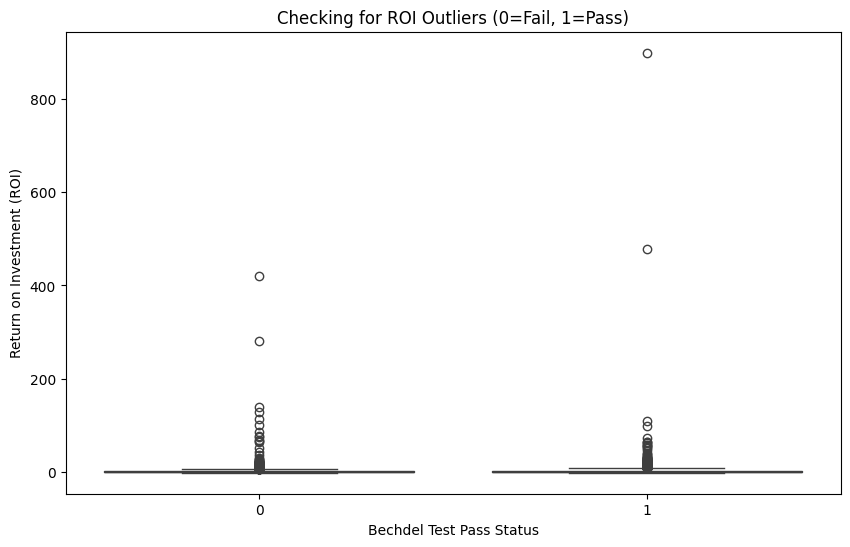

In [28]:
# Creating a boxplot of ROI by Bechdel Pass status
plt.figure(figsize=(10, 6))
sns.boxplot(x='bechdel_pass', y='ROI', data=merged_modern)

plt.title('Checking for ROI Outliers (0=Fail, 1=Pass)')
plt.ylabel('Return on Investment (ROI)')
plt.xlabel('Bechdel Test Pass Status')
plt.show()

There are definitely some outliers! Let's take a closer look.

In [29]:
# Creating a table of movies with ROI > 50
high_roi_table = merged_modern[merged_modern['ROI'] > 50].copy()

# Sorting them by ROI (highest first) so the table is easier to read
high_roi_table = high_roi_table.sort_values(by='ROI', ascending=False)

# Displaying the results
print(f"Number of extreme outliers (ROI > 50): {len(high_roi_table)}")
display(high_roi_table)

Number of extreme outliers (ROI > 50): 26


,title_bechdel,year,bechdelrating,budget,revenue,genre1,runtime,ROI,bechdel_pass
1437,Paranormal Activity,2007,3,215000,193355800,Horror,85,898.33,1
2755,Secret Superstar,2017,3,286284,137416709,Drama,150,479.00,1
1018,Open Water,2003,1,130000,54667954,Adventure,79,419.52,0
279,El Mariachi,1992,0,7225,2040920,Action,81,281.48,0
3111,Skinamarink,2022,0,15000,2100000,Horror,100,139.00,0
1315,Once,2006,2,160000,20710513,Drama,85,128.44,0
1100,Napoleon Dynamite,2004,1,400000,46118097,Comedy,95,114.30,0
1189,Keeping Mum,2005,3,169000,18564702,Comedy,103,108.85,1
1735,Catfish,2010,0,30000,3045943,Documentary,87,100.53,0
617,Kuch Kuch Hota Hai,1998,3,153000,15306000,Comedy,185,99.04,1


Paranormal Activity has the highest ROI by far with 898. With our average ROIs down in the 3-4 range, it may make sense for us to either cut the top 1% of ROIs and/or use median over mean down the line.

First, let's check how passing v. non-passing films are represented among films with ROI over 50.

In [30]:
# Calculating percent of passing v. non-passing films in the table
roi_percentages = high_roi_table['bechdel_pass'].value_counts(normalize=True) * 100

print("\nPercentage in the High ROI Table:")
print(roi_percentages)


Percentage in the High ROI Table:
bechdel_pass
1   50.00
0   50.00
Name: proportion, dtype: float64


An exact 50/50 split!

Since we now know about the outliers, let's compare the median ROIs and budgets.

In [31]:
# Checking median ROI of passing v. non-passing
roi_median_comparison = merged_modern.groupby('bechdel_pass')['ROI'].median()
print("Median ROI by Bechdel Status (0=Fail, 1=Pass):")
print(roi_median_comparison)

Median ROI by Bechdel Status (0=Fail, 1=Pass):
bechdel_pass
0   0.99
1   1.11
Name: ROI, dtype: float64


In [32]:
# Checking median budget of passing v. non-passing
budget_median_comparison = merged_modern.groupby('bechdel_pass')['budget'].median()
print("Median budget by Bechdel Status (0=Fail, 1=Pass):")
print(budget_median_comparison)

Median budget by Bechdel Status (0=Fail, 1=Pass):
bechdel_pass
0   27,000,000.00
1   20,000,000.00
Name: budget, dtype: float64


Our previous findings held up albeit they are now much more resistant to outliers since we compared medians. Bechdel Test passing films continue to appear to return slightly more profit with slightly lower budgets.

The search for outliers showed another trend in movie profitability: Horrors tend to have high returns since they can be produced for very low budgets, often in the wods or in someone's house. Let's look at ROI and budget per genre.

First, let's see how many movies we have per genre in case we have a genre with too few entries skewing the data.

In [33]:
# Counting the number of movies for each primary genre
genre_counts = merged_modern['genre1'].value_counts()

print("Number of movies per genre:")
print(genre_counts)

Number of movies per genre:
genre1
Action         941
Comedy         792
Drama          509
Adventure      307
Crime          201
Biography      186
Horror         159
Animation       24
Fantasy         18
Mystery         13
Documentary      6
Sci-Fi           3
Family           2
Thriller         2
Name: count, dtype: int64


Unsurprisingly, there are a lot of action movies. I am concerned about the low number of entries for Animation, Fantasy, Mystery, Documentary, Sci-Fi, Family and Thriller. It may be worth it to combine these into an "Other" category.

In [34]:
# Finding genres with counts less than or equal to 20
low_counts = merged_modern['genre1'].value_counts()
low_count_genres = low_counts[low_counts <= 20].index

# Replacing them as "other"
merged_modern['genre1'] = merged_modern['genre1'].replace(low_count_genres, 'Other')

In [35]:
# Checking
genre_counts = merged_modern['genre1'].value_counts()

print("Number of movies per genre:")
print(genre_counts)

Number of movies per genre:
genre1
Action       941
Comedy       792
Drama        509
Adventure    307
Crime        201
Biography    186
Horror       159
Other         44
Animation     24
Name: count, dtype: int64


Now I have 55 in the "Other" category. Let's look at ROI and budget per genre.

In [36]:
# Grouping by genre and calculating mean and median ROI
genre_roi_stats = merged_modern.groupby('genre1')['ROI'].agg(['mean', 'median'])

# Sorting by median to see which genres are most consistently profitable
genre_roi_stats = genre_roi_stats.sort_values(by='median', ascending=False)

# Displaying the table
print("Mean vs Median ROI per Genre:")
display(genre_roi_stats)

Mean vs Median ROI per Genre:


,mean,median
genre1,,
Horror,14.34,2.54
Adventure,3.81,1.54
Action,2.25,1.20
Comedy,3.01,0.96
Other,4.41,0.80
Biography,1.64,0.61
Drama,3.96,0.59
Crime,1.87,0.58
Animation,1.93,0.26


As suspected, horror leads in ROI but that could also be the result of Paranormal Activity's heavy weight.

A final exploration of the data I'd like to complete in Milestone 1 is examining the ROI of Bechdel passing movies pre-2014 and post-2014.

As mentioned in the introduction, post-2014 saw the #MeToo movement ignite an international modern women's rights movement, and anecdotally, that appeared to correlate with increased female-centric media. My hypothesis is that average ROI for passing films was lower after 2014 since more money was invested by larger production companies. Let's take a look by creating a new "era" feature and looking at mean and median ROI per era for passing and non-passing movies.

In [37]:
# 1. Creating a column to define the eras of pre- and post-2014
merged_modern['era'] = np.where(merged_modern['year'] < 2014, 'Pre-2014', 'Post-2014 (Modern)')

# 2. Grouping by "era" and Bechdel Status to get Mean and Median ROI
era_comparison = merged_modern.groupby(['era', 'bechdel_pass']).agg(
    movie_count=('ROI', 'count'),
    mean_roi=('ROI', 'mean'),
    median_roi=('ROI', 'median')
).reset_index()

# 3. For clarity, mapping 0/1 to 'Fail'/'Pass'
era_comparison['bechdel_pass'] = era_comparison['bechdel_pass'].map({0: 'Fail', 1: 'Pass'})

# Displaying the results
print("Comprehensive ROI Comparison Pre-2014 & Post-2014")
display(era_comparison)

Comprehensive ROI Comparison Pre-2014 & Post-2014


,era,bechdel_pass,movie_count,mean_roi,median_roi
0,Post-2014 (Modern),Fail,329,2.31,0.83
1,Post-2014 (Modern),Pass,571,3.80,1.20
2,Pre-2014,Fail,1047,3.45,1.01
3,Pre-2014,Pass,1216,3.58,1.07


Interestingly, my hypothesis looks incorrect. Post-2014 passing films increased in mean and median ROI over pre-2014 passing films. Perhaps even more interestingly, non-passing films declined from pre- to post-2014 in mean and median ROI.

Let's look at how ROI has changed over time for passing v. non-passing films. First, I'm going to create a feature that lets me sort by decade.

In [38]:
# Creating the 'decade' column
# This uses floor division (//) to drop the last digit, then multiplies by 10
merged_modern['decade'] = (merged_modern['year'] // 10) * 10

# Verifying the new column
display(merged_modern[['title_bechdel', 'year', 'decade']].head())

,title_bechdel,year,decade
0,A Room with a View,1985,1980
1,A View to a Kill,1985,1980
2,After Hours,1985,1980
3,Back to the Future,1985,1980
4,Brazil,1985,1980


Now I will plot passing median ROI over time v. non-passing. I am choosing median to limit the impact of outliers.

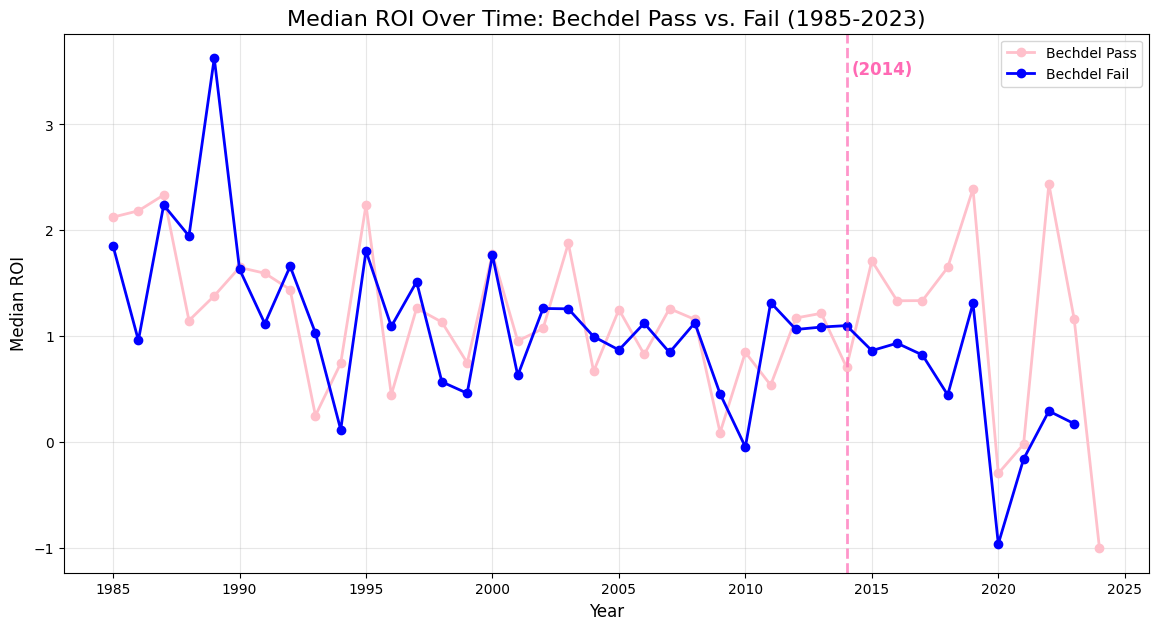

In [39]:
# Grouping by year and pass status (1=Pass, 0=Fail) and taking the median ROI
roi_trends = merged_modern.groupby(['year', 'bechdel_pass'])['ROI'].median().unstack()

# 2. Setting up the figure
plt.figure(figsize=(14, 7))

# 3. Plotting the main lines
# Pass (1) is Pink, Fail (0) is Blue
plt.plot(roi_trends.index, roi_trends[1], label='Bechdel Pass', color='pink', marker='o', linewidth=2)
plt.plot(roi_trends.index, roi_trends[0], label='Bechdel Fail', color='blue', marker='o', linewidth=2)

# 4. Adding the vertical line at 2014
plt.axvline(x=2014, color='hotpink', linestyle='--', linewidth=2, alpha=0.7)

# 5. Adding a text label for the line
plt.text(2014.2, plt.gca().get_ylim()[1] * 0.9, '(2014)',
         color='hotpink', fontweight='bold', fontsize=12)

# 6. Formatting
plt.title('Median ROI Over Time: Bechdel Pass vs. Fail (1985-2023)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Median ROI', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

This is very interesting. We can see clearly how the ROI for movies that pass the Bechdel Test v. those that don't have inverted over time. (We can also clearly see the impact of COVID-19 on movie theatre business.)

In [42]:
%shell jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/Yawn_Milestone1.ipynb" --output INDEX.html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/Yawn_final.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 829080 bytes to /content/drive/MyDrive/Colab Notebooks/INDEX.html
